# Notebook 3 — Monant · Gemma-3 Classifier & Benchmark
## Gemma-3 embeddings → Classifieurs ML · Benchmark vs TF-IDF Baselines

**Projet :** A Multi-Source Benchmark for CVD Monant dataset
**Modèle :** `google/gemma-3-4b-it` (HuggingFace)  
**Request :** Run two first jupiter notebook NB1 and NB2

--- 

| Aspect | BioBERT | Gemma-3-4B |
|---|---|---|
| Architecture | Encoder (BERT) | Decoder (Causal LM) |
| Embedding token | CLS token (index 0) | **Last non-padding token** |
| Loader | `AutoModel` | `AutoModelForCausalLM` |
| Tokenizer | `AutoTokenizer` | `AutoProcessor` |


In [1]:
# ── Imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import glob
import re
import json
import unicodedata
from pathlib import Path

import torch
from transformers import AutoProcessor, AutoModelForCausalLM

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, make_scorer
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK')
print(f'   torch   {torch.__version__}')
print(f'   device  {DEVICE}')
print(f'   CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

 Imports OK
   torch   2.10.0+cu128
   device  cpu
   CUDA available: False


* tu use google/gemma-3-4b-it, you need a token from huggingface and to be logged in with the CLI (huggingface-cli login)

In [2]:
from huggingface_hub import login
login()

In [3]:
MODEL_ID = "google/gemma-3-4b-it"

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto"
)
model.eval()

print(f' Gemma-3 loaded: {MODEL_ID}')
print(f'   Parameters : {sum(p.numel() for p in model.parameters()):,}')
tokenizer = processor.tokenizer if hasattr(processor, 'tokenizer') else processor

/home/diankham/anaconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


 Gemma-3 loaded: google/gemma-3-4b-it
   Parameters : 4,300,079,472


In [4]:
def extract_gemma_embeddings(
    texts, processor, model, batch_size=1, max_length=512, pooling='last'
):
    """
    Extract fixed-size embeddings from a list of texts using Gemma-3.

    Args:
        texts      : list/array of raw strings to encode.
        processor  : HuggingFace AutoProcessor for Gemma-3.
        model      : HuggingFace AutoModelForCausalLM already loaded.
        batch_size : number of texts per forward pass (1–4 recommended for 4B).
        max_length : maximum number of tokens per text.
        pooling    : 'last' for last non-padding token, 'mean' for mean pooling.

    Returns:
        np.ndarray of shape (n_texts, hidden_size).
    """

    all_embeddings = []
    n = len(texts)

    # Use the tokenizer from the processor
    tok = processor.tokenizer if hasattr(processor, 'tokenizer') else processor

    print(f'Extracting {pooling}-pooled Gemma-3 embeddings ')
    print(f'   {n} texts | batch_size={batch_size} | max_length={max_length}')

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch = list(texts[start:end])

        # Tokenize the current batch
        encoded = tok(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

       
        input_device = next(model.parameters()).device
        encoded = {k: v.to(input_device) for k, v in encoded.items()}

        with torch.no_grad():
            # output_hidden_states=True is required to get the hidden state matrix
            outputs = model(
                **encoded,
                output_hidden_states=True
            )

        last_hidden = outputs.hidden_states[-1]  

        attention_mask = encoded['attention_mask']  

        if pooling == 'last':
            # Index of the last non-padding token per sequence
            # attention_mask: 1 = real token, 0 = padding
            seq_lengths = attention_mask.sum(dim=1) - 1  # (batch,)
            batch_idx = torch.arange(last_hidden.size(0), device=last_hidden.device)
            embeddings = last_hidden[batch_idx, seq_lengths, :] 
            
        elif pooling == 'mean':
            # Mean over non-padding tokens
            mask = attention_mask.unsqueeze(-1).float()  # (batch, seq_len, 1)
            embeddings = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1)  # (batch, hidden_size)

        else:
            raise ValueError(f'Unknown pooling: {pooling}. Choose "last" or "mean".')

        all_embeddings.append(embeddings.cpu().float().numpy())

        if (start // batch_size) % 10 == 0:
            print(f'   [{end}/{n}] done', end='\r')

    print(f'   [{n}/{n}] done        ')

    result = np.vstack(all_embeddings)
    print(f' Embedding matrix shape: {result.shape}')
    return result

In [5]:
CSV_PATH = Path('full_data/claims.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        'Filtered dataset not found: mumin_claims_cardio_diabete_baseline_ready.csv\n'
        'Run NB1 first to generate it.'
    )

In [6]:
df = pd.read_csv(CSV_PATH)
print(f' Dataset loaded: {len(df)} claims')
df.shape
df.head()


 Dataset loaded: 3423 claims


,id,name,statement,description,category,rating,queries,created_at,updated_at
0,6771,NaN,Dawn dish soap contains ammonia even though it...,Could Mixing Dawn Dish Soap with Clorox Bleach...,"{medical,science}",mixture,NaN,2020-06-28 21:40:18.799231+02,2020-06-28 21:40:18.799231+02
1,799,NaN,Do probiotics help with Irritable Bowel Syndrome?,NaN,{medical},true,NaN,2019-12-13 14:27:18.231183+01,2022-01-28 12:01:30.203904+01
2,2468,NaN,Is blue light harmful to our eyes?,<p>It seems reasonable to reduce exposure to b...,{medical},unknown,NaN,2019-12-13 14:31:00.722277+01,2022-02-04 12:13:34.253699+01
3,2634,NaN,Does caffeine help asthma sufferers?,"<p><a href=""https://www.nytimes.com/2010/11/30...",{medical},unknown,NaN,2019-12-13 14:31:25.271774+01,2022-01-28 12:01:22.380887+01
4,2745,NaN,Is there a link between diet and vasculitis?,NaN,{medical},unknown,NaN,2019-12-13 14:31:40.382026+01,2022-02-03 12:08:42.081948+01


In [7]:
df['text'] = (
    df['name'].fillna('').astype(str) + ' ' +
    df['statement'].fillna('').astype(str) + ' ' +
    df['description'].fillna('').astype(str)
)
df.head()

,id,name,statement,description,category,rating,queries,created_at,updated_at,text
0,6771,NaN,Dawn dish soap contains ammonia even though it...,Could Mixing Dawn Dish Soap with Clorox Bleach...,"{medical,science}",mixture,NaN,2020-06-28 21:40:18.799231+02,2020-06-28 21:40:18.799231+02,Dawn dish soap contains ammonia even though i...
1,799,NaN,Do probiotics help with Irritable Bowel Syndrome?,NaN,{medical},true,NaN,2019-12-13 14:27:18.231183+01,2022-01-28 12:01:30.203904+01,Do probiotics help with Irritable Bowel Syndr...
2,2468,NaN,Is blue light harmful to our eyes?,<p>It seems reasonable to reduce exposure to b...,{medical},unknown,NaN,2019-12-13 14:31:00.722277+01,2022-02-04 12:13:34.253699+01,Is blue light harmful to our eyes? <p>It seem...
3,2634,NaN,Does caffeine help asthma sufferers?,"<p><a href=""https://www.nytimes.com/2010/11/30...",{medical},unknown,NaN,2019-12-13 14:31:25.271774+01,2022-01-28 12:01:22.380887+01,Does caffeine help asthma sufferers? <p><a hr...
4,2745,NaN,Is there a link between diet and vasculitis?,NaN,{medical},unknown,NaN,2019-12-13 14:31:40.382026+01,2022-02-03 12:08:42.081948+01,Is there a link between diet and vasculitis?


In [8]:
rating_aliases = {
    'false': 'false',
    'mostly-false': 'almost false',
    'almost false': 'almost false',
    'mostly true': 'almost true',
    'mostly-true': 'almost true',
    'almost true': 'almost true',
    'true': 'true',
}

valid_ratings = set(rating_aliases)
df = df[df['rating'].isin(valid_ratings)].copy()
df = df[['id', 'text', 'rating']].reset_index(drop=True)
df.head()
df.shape

(1341, 3)

In [9]:
# Embedding cache — avoid re-extracting every time
EMBEDDING_CACHE_PATH = 'gemma3_embeddings.npy'

if os.path.exists(EMBEDDING_CACHE_PATH):
    print(f'Loading cached embeddings from {EMBEDDING_CACHE_PATH} ...')
    X_embeddings = np.load(EMBEDDING_CACHE_PATH)
    print(f' Embeddings loaded: {X_embeddings.shape}')
else:
    print('No cached embeddings found, extracting from Gemma-3 — this may take a while... (30 mins expected)')
    X_embeddings = extract_gemma_embeddings(
        texts=df['text'],
        processor=processor,
        model=model,
        batch_size=1,       
        max_length=200,
        pooling='last'     
    )
    np.save(EMBEDDING_CACHE_PATH, X_embeddings)
    print(f'Embeddings saved to cache: {EMBEDDING_CACHE_PATH}')

print('All steps completed successfully.')

Loading cached embeddings from gemma3_embeddings.npy ...
 Embeddings loaded: (1341, 2560)
All steps completed successfully.


In [10]:
from sklearn.metrics.pairwise import cosine_similarity

# Cardiovascular / diabetes query terms (same as NB3 BioBERT)
queries = [
    "cardiovascular disease", "cardiovascular disorders", "heart disease", "cardiac disease",
    "coronary artery disease", "coronary heart disease", "ischemic heart disease",
    "myocardial ischemia", "myocardial infarction", "heart attack", "acute coronary syndrome",
    "stroke", "ischemic stroke", "hemorrhagic stroke", "cerebrovascular accident",
    "transient ischemic attack", "tia", "hypertension", "high blood pressure",
    "arterial hypertension", "heart failure", "congestive heart failure",
    "arrhythmia", "atrial fibrillation", "ventricular arrhythmia",
    "chest pain", "angina", "stable angina", "unstable angina",
    "shortness of breath", "dyspnea", "exertional dyspnea", "palpitations",
    "tachycardia", "bradycardia", "fatigue", "chronic fatigue",
    "exercise intolerance", "dizziness", "vertigo", "lightheadedness",
    "syncope", "fainting", "loss of consciousness", "edema", "peripheral edema", "swelling",
    "smoking", "tobacco use", "nicotine exposure", "obesity", "overweight", "bmi",
    "body mass index", "high cholesterol", "hyperlipidemia", "ldl", "hdl", "triglycerides",
    "diabetes", "insulin resistance", "sedentary lifestyle", "physical inactivity",
    "family history", "genetic predisposition", "age", "male sex", "stress", "poor diet",
    "statins", "beta-blockers", "ace inhibitors", "arbs", "antihypertensive drugs",
    "anticoagulants", "blood thinners", "aspirin therapy", "antiplatelet therapy",
    "angioplasty", "percutaneous coronary intervention", "stent", "coronary stent",
    "bypass surgery", "coronary artery bypass graft", "cardiac rehabilitation",
    "ecg", "electrocardiogram", "ekg", "blood pressure", "ambulatory blood pressure monitoring",
    "cholesterol levels", "lipid panel", "troponin", "cardiac biomarkers",
    "echocardiogram", "cardiac ultrasound", "stress test", "exercise tolerance test",
    "ct angiography",
    "type 1 diabetes", "type 2 diabetes", "gestational diabetes", "prediabetes",
    "latent autoimmune diabetes", "lada", "mody", "maturity onset diabetes of the young",
    "frequent urination", "polyuria", "excessive thirst", "polydipsia", "polyphagia",
    "increased appetite", "weight loss", "unexplained weight loss", "blurred vision",
    "slow wound healing", "fatigue", "lethargy",
    "insulin", "insulin therapy", "metformin", "oral hypoglycemics", "glucose-lowering drugs",
    "sulfonylureas", "glp-1 agonists", "sglt2 inhibitors", "lifestyle intervention",
    "diet control", "carbohydrate counting", "continuous glucose monitoring", "cgm",
    "blood glucose", "blood sugar", "fasting glucose", "postprandial glucose",
    "hba1c", "glycated hemoglobin", "insulin level", "glucose tolerance test", "ogtt", "c-peptide",
    "neuropathy", "diabetic neuropathy", "nephropathy", "kidney disease",
    "retinopathy", "diabetic retinopathy", "diabetic foot ulcer",
    "cardiovascular complications", "macrovascular complications", "microvascular complications"
]


def embed_queries_gemma(queries, processor, model, max_length=128):
    """Embed short query strings using Gemma-3 (last-token pooling)."""
    model.eval()
    tok = processor.tokenizer if hasattr(processor, 'tokenizer') else processor
    enc = tok(
        queries,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    input_device = next(model.parameters()).device
    enc = {k: v.to(input_device) for k, v in enc.items()}
    with torch.no_grad():
        outputs = model(**enc, output_hidden_states=True)
    last_hidden = outputs.hidden_states[-1]
    seq_lengths = enc['attention_mask'].sum(dim=1) - 1
    batch_idx = torch.arange(last_hidden.size(0), device=last_hidden.device)
    embeddings = last_hidden[batch_idx, seq_lengths, :]
    return embeddings.cpu().float().numpy()


q_emb = embed_queries_gemma(queries, processor, model)
df['topic_score'] = cosine_similarity(X_embeddings, q_emb).max(axis=1)

SEUIL_STRICT = 0.25
selected_df = (
    df[df['topic_score'] >= SEUIL_STRICT]
    .sort_values('topic_score', ascending=False)
    .copy()
)

print(f'Selected {len(selected_df)} rows')
selected_df.head(10)
selected_df.to_csv('full_data/claims_filtered_gemma3.csv', index=False)

Selected 1151 rows


In [11]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(selected_df['rating'].values)
X = X_embeddings[selected_df.index]  
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Label mapping: {dict(enumerate(label_encoder.classes_))}') 

X shape: (1151, 2560), y shape: (1151,)
Label mapping: {0: 'false', 1: 'mostly-false', 2: 'mostly-true', 3: 'true'}


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [13]:
# ── Classifiers

clf_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    ))
])


gemma_models = {
    'Gemma3 + LR':        clf_lr,
    'Gemma3 + LinearSVC': clf_svm,
    'Gemma3 + MLP':       clf_mlp,
}

for name in gemma_models:
    print(f'   • {name}')

   • Gemma3 + LR
   • Gemma3 + LinearSVC
   • Gemma3 + MLP


In [14]:
import joblib
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results_bb = {}

for name, clf in gemma_models.items():
    cv = cross_validate(
        clf, X, y,
        cv=SKF,
        scoring={
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score=False,
        n_jobs=-1
    )
    cv_results_bb[name] = cv
    joblib.dump(cv_results_bb, "cv_results_gemma.joblib")
    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()


/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


── Gemma3 + LR ──
  Accuracy  : 0.7941 ± 0.0163
  F1 macro  : 0.3958 ± 0.0577
  Precision : 0.4127 ± 0.0742
  Recall    : 0.3886 ± 0.0489



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


── Gemma3 + LinearSVC ──
  Accuracy  : 0.7715 ± 0.0191
  F1 macro  : 0.3861 ± 0.0296
  Precision : 0.3981 ± 0.0532
  Recall    : 0.3846 ± 0.0244



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

── Gemma3 + MLP ──
  Accuracy  : 0.7993 ± 0.0286
  F1 macro  : 0.3459 ± 0.0288
  Precision : 0.3559 ± 0.0401
  Recall    : 0.3452 ± 0.0232



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
test_results_g4 = {}

for name, clf in gemma_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    test_results_g4[name] = {
        'y_pred'    : y_pred,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'prec_macro': precision_score(y_test, y_pred, average='macro'),
        'rec_macro' : recall_score(y_test, y_pred, average='macro'),
        'f1_macro'  : f1_score(y_test, y_pred, average='macro')
    }

    print(f'── {name} — Test Set ──')
    
    print(classification_report(y_test, y_pred, labels=range(len(label_encoder.classes_)), target_names=label_encoder.classes_))

── Gemma3 + LR — Test Set ──
              precision    recall  f1-score   support

       false       0.84      0.92      0.88       179
mostly-false       0.25      0.10      0.14        10
 mostly-true       0.40      0.29      0.33         7
        true       0.60      0.43      0.50        35

    accuracy                           0.79       231
   macro avg       0.52      0.43      0.46       231
weighted avg       0.76      0.79      0.77       231



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


── Gemma3 + LinearSVC — Test Set ──
              precision    recall  f1-score   support

       false       0.83      0.86      0.84       179
mostly-false       0.25      0.10      0.14        10
 mostly-true       0.50      0.29      0.36         7
        true       0.41      0.43      0.42        35

    accuracy                           0.74       231
   macro avg       0.50      0.42      0.44       231
weighted avg       0.73      0.74      0.73       231

── Gemma3 + MLP — Test Set ──
              precision    recall  f1-score   support

       false       0.82      0.98      0.89       179
mostly-false       0.00      0.00      0.00        10
 mostly-true       1.00      0.14      0.25         7
        true       0.76      0.37      0.50        35

    accuracy                           0.82       231
   macro avg       0.65      0.37      0.41       231
weighted avg       0.78      0.82      0.78       231



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


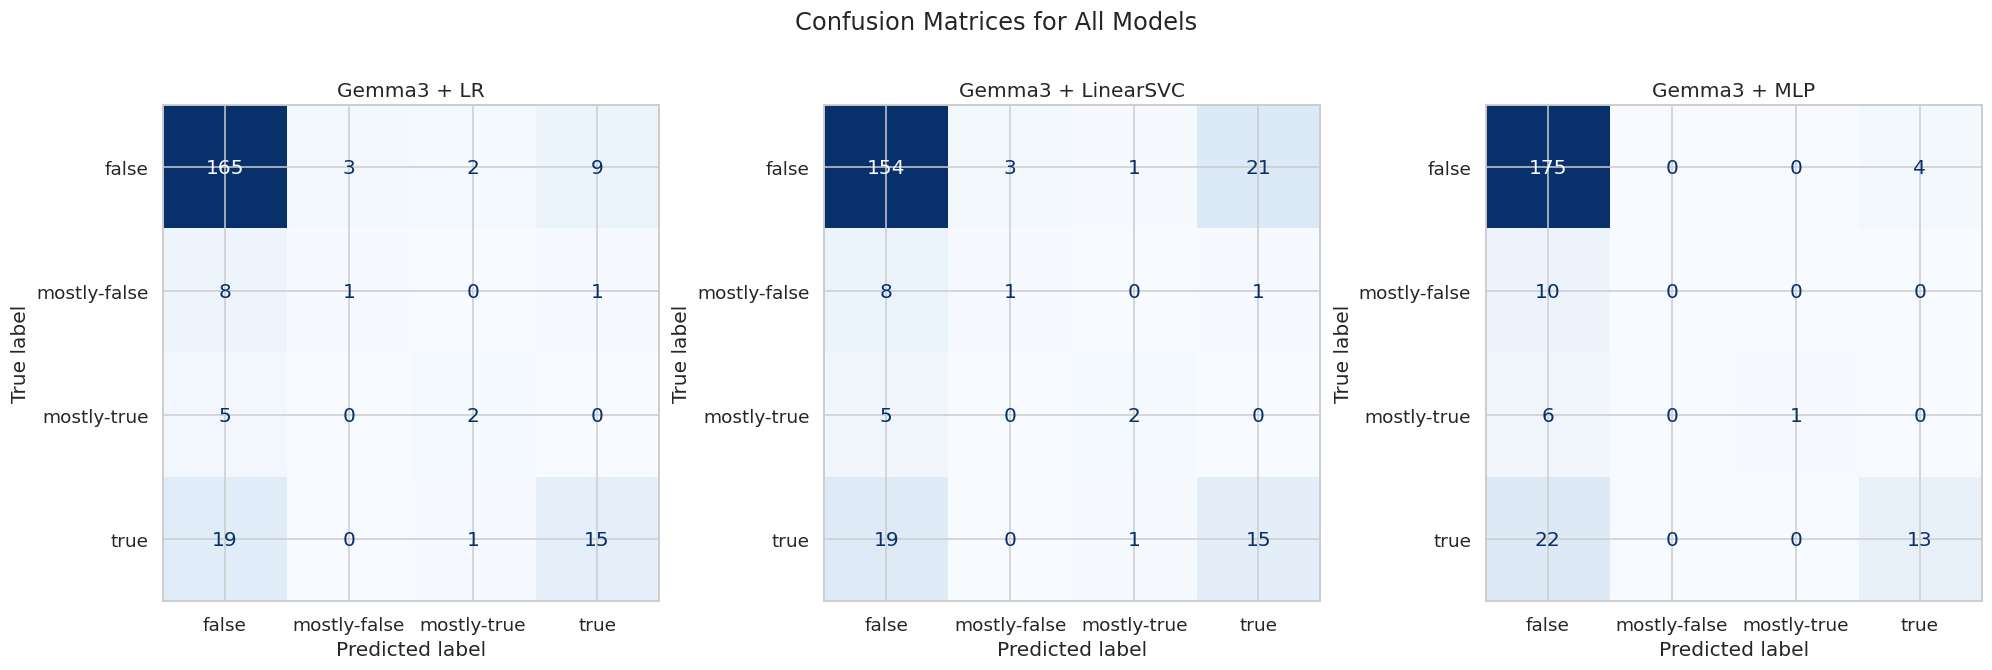

Classification report for Gemma3 + LR:
              precision    recall  f1-score   support

       false       0.84      0.92      0.88       179
mostly-false       0.25      0.10      0.14        10
 mostly-true       0.40      0.29      0.33         7
        true       0.60      0.43      0.50        35

    accuracy                           0.79       231
   macro avg       0.52      0.43      0.46       231
weighted avg       0.76      0.79      0.77       231

--------------------------------------------------------------------------------
Classification report for Gemma3 + LinearSVC:
              precision    recall  f1-score   support

       false       0.83      0.86      0.84       179
mostly-false       0.25      0.10      0.14        10
 mostly-true       0.50      0.29      0.36         7
        true       0.41      0.43      0.42        35

    accuracy                           0.74       231
   macro avg       0.50      0.42      0.44       231
weighted avg       

/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [16]:
models = list(gemma_models.items())
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 6), constrained_layout=True)

for ax, (name, clf) in zip(axes, models):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrices for All Models', y=1.02)
plt.show()

for name, clf in models:
    y_pred = clf.predict(X_test)
    print(f'Classification report for {name}:')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    print('-' * 80)

In [17]:

print('=' * 100)

# Header
header = f'{"Modèle":<30} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"CV F1±σ":>13}'
print(header)
print('-' * 80)

for name, res in cv_results_bb.items():
    cv = cv_results_bb.get(name)
    if cv is not None and 'test_f1_macro' in cv:
        cv_f1_mean = cv['test_f1_macro'].mean()
        cv_f1_std = cv['test_f1_macro'].std()
    else:
        cv_f1_mean = float('nan')
        cv_f1_std = float('nan')

    acc_mean = res['test_accuracy'].mean()
    prec_mean = res['test_precision_macro'].mean()
    rec_mean = res['test_recall_macro'].mean()
    f1_mean = res['test_f1_macro'].mean()

    row = (
        f'{name:<30} '
        f'{acc_mean:>7.3f} '
        f'{prec_mean:>7.3f} '
        f'{rec_mean:>7.3f} '
        f'{f1_mean:>7.3f} '
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

print('=' * 100)
print()

Modèle                             Acc    Prec  Recall  F1-mac       CV F1±σ
--------------------------------------------------------------------------------
Gemma3 + LR                      0.794   0.413   0.389   0.396  0.396±0.058
Gemma3 + LinearSVC               0.771   0.398   0.385   0.386  0.386±0.030
Gemma3 + MLP                     0.799   0.356   0.345   0.346  0.346±0.029

